# Exporting GroupGraphs to SDF, MOL, XYZ, PDB

Grouper enumerates molecular structures as `GroupGraph` objects. To use those structures in molecular dynamics (GROMACS, OpenMM, LAMMPS), docking (AutoDock Vina, Glide), quantum chemistry (Gaussian, ORCA, Psi4), or visualization (PyMOL, VMD, ChimeraX), you need them in one of the standard chemical-file formats.

This notebook demonstrates `Grouper.exports`, which adds five methods to every `GroupGraph`:

| method | format | typical consumer |
|---|---|---|
| `gG.to_3d()` | RDKit Mol with 3D coords | further RDKit / Python work |
| `gG.to_sdf()` | SDF (single or multi-mol) | KNIME, Pipeline Pilot, RDKit pipelines |
| `gG.to_mol()` | V2000 MOL block | legacy single-molecule tools |
| `gG.to_xyz()` | XYZ coords | Gaussian, ORCA, NWChem, Psi4 |
| `gG.to_pdb()` | PDB | PyMOL, VMD, AutoDock Vina |

Plus `Grouper.exports.write_sdf(graphs, path)` for batch output of every structure from an `exhaustive_generate` run into one multi-molecule SDF file — with optional predicted properties attached to each entry.

**Run all cells** to see outputs. Estimated runtime: under 10 seconds.

Requirements: `Grouper`, `rdkit`. Optional for the in-notebook 3D view: `py3Dmol`.

In [1]:
import tempfile, os
from pathlib import Path

from rdkit import Chem
from rdkit.Chem import Draw

from Grouper import Group, GroupGraph, exhaustive_generate
from Grouper.exports import to_3d_mol, write_sdf, EmbedError

## 1. Build a GroupGraph the usual way

Construct n-propanol (CCCO) by hand from atomic groups, just so the rest of the notebook has something concrete to operate on. In real usage this object would come from `exhaustive_generate`, `random_generate`, or `fragment(...)`.

SMILES:  CCCO
Nodes:   4 groups


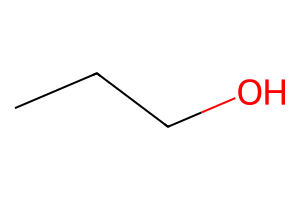

In [2]:
gG = GroupGraph()
gG.add_node("methyl",     "C", [0])         # 1 port
gG.add_node("methylene1", "C", [0, 0])      # 2 ports
gG.add_node("methylene2", "C", [0, 0])      # 2 ports
gG.add_node("hydroxyl",   "O", [0])         # 1 port
gG.add_edge((0, 0), (1, 0))                  # methyl  — methylene1
gG.add_edge((1, 1), (2, 0))                  # methylene1 — methylene2
gG.add_edge((2, 1), (3, 0))                  # methylene2 — hydroxyl

print(f"SMILES:  {gG.to_smiles()}")
print(f"Nodes:   {len(gG.nodes)} groups")
Draw.MolToImage(Chem.MolFromSmiles(gG.to_smiles()), size=(300, 200))

## 2. Generate 3D coordinates

`gG.to_3d()` runs RDKit's ETKDG distance-geometry embedding followed by force-field minimization. Default force field is **MMFF94** (more accurate); falls back to **UFF** automatically if MMFF lacks parameters for some atom in your molecule. Pass `force_field="uff"` to force UFF, or `"none"` to skip minimization (just the embed).

In [3]:
mol_3d = gG.to_3d(seed=42)
print(f"Atoms (incl. explicit H):  {mol_3d.GetNumAtoms()}")
print(f"Conformers:                 {mol_3d.GetNumConformers()}")

conf = mol_3d.GetConformer()
print("\nFirst 5 atom positions (Å):")
print(f"  {'idx':>3}  {'symbol':>6}  {'x':>8}  {'y':>8}  {'z':>8}")
for i in range(min(5, mol_3d.GetNumAtoms())):
    a = mol_3d.GetAtomWithIdx(i)
    p = conf.GetAtomPosition(i)
    print(f"  {i:>3}  {a.GetSymbol():>6}  {p.x:>8.3f}  {p.y:>8.3f}  {p.z:>8.3f}")

Atoms (incl. explicit H):  12
Conformers:                 1

First 5 atom positions (Å):
  idx  symbol         x         y         z
    0       C    -1.306    -0.015     0.502
    1       C    -0.141     0.649    -0.217
    2       C     0.913    -0.356    -0.663
    3       O     1.492    -1.013     0.456
    4       H    -2.054     0.734     0.782


### Optional: 3D view in the notebook

If `py3Dmol` is installed, render the conformer interactively. Skip this cell if not.

In [4]:
try:
    import py3Dmol
    view = py3Dmol.view(width=300, height=300)
    view.addModel(Chem.MolToMolBlock(mol_3d), "mol")
    view.setStyle({"stick": {}, "sphere": {"scale": 0.25}})
    view.zoomTo()
    view.show()
except ImportError:
    print("(py3Dmol not installed — skipping interactive view; install via `pip install py3Dmol`)")

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

## 3. The four file formats

Each export method returns a string when called with no arguments — useful for embedding in a notebook or piping to another tool. Pass `path=...` to write to disk instead (returns `None`).

In [5]:
for fmt in ("sdf", "mol", "xyz", "pdb"):
    text = getattr(gG, f"to_{fmt}")()
    print(f"=== gG.to_{fmt}() ===")
    # Show first 8 lines + total length so we don't drown the cell
    for line in text.splitlines()[:8]:
        print(f"  {line}")
    print(f"  ... ({len(text.splitlines())} lines total)\n")

=== gG.to_sdf() ===
  
       RDKit          3D
  
   12 11  0  0  0  0  0  0  0  0999 V2000
     -1.3061   -0.0154    0.5024 C   0  0  0  0  0  0  0  0  0  0  0  0
     -0.1415    0.6492   -0.2174 C   0  0  0  0  0  0  0  0  0  0  0  0
      0.9134   -0.3560   -0.6626 C   0  0  0  0  0  0  0  0  0  0  0  0
      1.4916   -1.0131    0.4565 O   0  0  0  0  0  0  0  0  0  0  0  0
  ... (29 lines total)

=== gG.to_mol() ===
  
       RDKit          3D
  
   12 11  0  0  0  0  0  0  0  0999 V2000
     -1.3061   -0.0154    0.5024 C   0  0  0  0  0  0  0  0  0  0  0  0
     -0.1415    0.6492   -0.2174 C   0  0  0  0  0  0  0  0  0  0  0  0
      0.9134   -0.3560   -0.6626 C   0  0  0  0  0  0  0  0  0  0  0  0
      1.4916   -1.0131    0.4565 O   0  0  0  0  0  0  0  0  0  0  0  0
  ... (28 lines total)

=== gG.to_xyz() ===
  12
  
  C     -1.306081   -0.015390    0.502396
  C     -0.141451    0.649158   -0.217435
  C      0.913381   -0.356018   -0.662629
  O      1.491570   -1.013051    0.4

## 4. Writing to disk

Same methods, but with a `path` argument. Returns `None`; the file appears at the given path.

In [6]:
with tempfile.TemporaryDirectory() as td:
    out_dir = Path(td)
    for fmt in ("sdf", "mol", "xyz", "pdb"):
        path = out_dir / f"propanol.{fmt}"
        getattr(gG, f"to_{fmt}")(path=str(path))
        print(f"  wrote {path.name}: {path.stat().st_size:>5} bytes")

  wrote propanol.sdf:  1060 bytes
  wrote propanol.mol:  1055 bytes
  wrote propanol.xyz:   484 bytes
  wrote propanol.pdb:  1079 bytes


## 5. Attaching properties to an SDF

SDF supports arbitrary `> <KEY>` property blocks per molecule. Useful for shipping predictions, source metadata, or experimental measurements alongside the structure so downstream tools can use them without a separate join step.

Pass `properties=...` (a dict) to `to_sdf` for a single molecule:

In [7]:
sdf = gG.to_sdf(
    name="propanol",
    properties={
        "smiles":     gG.to_smiles(),
        "source":     "Grouper.exhaustive_generate",
        "library":    "{methyl, methylene, hydroxyl}",
        "comment":    "hand-built example",
    },
)
# Show only the property-block section (after `M  END`)
print(sdf[sdf.find("M  END"):])

M  END
>  <smiles>  (1) 
CCCO

>  <source>  (1) 
Grouper.exhaustive_generate

>  <library>  (1) 
{methyl, methylene, hydroxyl}

>  <comment>  (1) 
hand-built example

$$$$



## 6. Batch SDF: an entire `exhaustive_generate` run with metadata

The realistic industrial use case. Generate a small library, attach a `properties_fn` callback that runs per-molecule, and write everything into a multi-molecule SDF that downstream pipelines can stream through.

`skip_failures=True` keeps the batch going past molecules whose 3D embedding fails (rare but not impossible — strained ring systems can defeat ETKDG). Each failure emits a `UserWarning` with the offending SMILES.

In [8]:
# Enumerate every n=3 GroupGraph over a {methyl, hydroxyl} library.
node_defs = {
    Group("methyl",   "C", [0, 0, 0, 0]),
    Group("hydroxyl", "O", [0, 0]),
}
results = list(exhaustive_generate(3, node_defs, num_procs=1))
print(f"exhaustive_generate(n=3, |library|=2) -> {len(results)} unique molecules")

# Define a per-molecule properties callback. In a real screening flow
# this would call JobackEstimate / a docking score / an ML predictor.
def attach_metadata(g):
    smi = g.to_smiles()
    return {
        "smiles":  smi,
        "n_nodes": len(g.nodes),
        "has_OH":  "yes" if "O" in smi else "no",
    }

with tempfile.TemporaryDirectory() as td:
    out = Path(td) / "library.sdf"
    n = write_sdf(results, str(out), properties_fn=attach_metadata, skip_failures=True)
    print(f"\nwrote {n} of {len(results)} molecules to {out.name} ({out.stat().st_size} bytes)")

    # Round-trip via RDKit's SDMolSupplier and pull out the property tags.
    supplier = Chem.SDMolSupplier(str(out))
    print("\nRound-tripped property block for each molecule in the SDF:")
    print(f"  {'SMILES':<8}  {'has_OH':<8}  {'n_nodes':<8}")
    for mol in supplier:
        if mol is None:
            continue
        print(f"  {mol.GetProp('smiles'):<8}  {mol.GetProp('has_OH'):<8}  {mol.GetProp('n_nodes'):<8}")

Using 1 processors (streaming)
100% (10/10)
Number of unique graphs: 10
exhaustive_generate(n=3, |library|=2) -> 10 unique molecules

wrote 10 of 10 molecules to library.sdf (7407 bytes)

Round-tripped property block for each molecule in the SDF:
  SMILES    has_OH    n_nodes 
  OCO       yes       3       
  C1OO1     yes       3       
  CCC       no        3       
  OOO       yes       3       
  CCO       yes       3       
  C1CO1     yes       3       
  O1OO1     yes       3       
  C1CC1     no        3       
  COO       yes       3       
  COC       yes       3       


>A geng -cd1D2 n=3 e=2-3
>A vcolg -m2T
>Z 2 graphs generated in 0.00 sec
>Z 2 graphs read from stdin; 10 coloured graphs written to stdout; 0.00 sec


## 7. Force-field choices and the embed pipeline

RDKit's ETKDG distance-geometry embedding gives a reasonable starting structure; the force-field minimization step relaxes it to a local energy minimum. For most organic molecules in Joback's element scope, MMFF94 (default) and UFF give similar results. UFF covers more atom types, MMFF is generally more accurate where parameters exist.

In [9]:
for ff in ("mmff94", "uff", "none"):
    m = gG.to_3d(seed=42, force_field=ff)
    conf = m.GetConformer()
    # Compute end-to-end distance (CH3 carbon to hydroxyl O) as a proxy
    # for the geometry the force field settled on.
    p0 = conf.GetAtomPosition(0)  # methyl carbon (heavy atom 0 after AddHs)
    # find the oxygen atom
    ox_idx = next(a.GetIdx() for a in m.GetAtoms() if a.GetSymbol() == "O")
    p_o = conf.GetAtomPosition(ox_idx)
    d = ((p0.x - p_o.x)**2 + (p0.y - p_o.y)**2 + (p0.z - p_o.z)**2) ** 0.5
    print(f"  force_field={ff!r:>10}  C–O end-to-end distance: {d:.3f} Å")

  force_field=  'mmff94'  C–O end-to-end distance: 2.971 Å
  force_field=     'uff'  C–O end-to-end distance: 2.971 Å
  force_field=    'none'  C–O end-to-end distance: 2.703 Å


## 8. When embedding fails

ETKDG isn't infallible — strained polycyclics, unusual valences, or just bad luck with the random seed can leave it without a feasible solution. The export module raises `EmbedError` with the offending SMILES, so a caller can decide whether to retry, skip, or fail the batch.

In [10]:
# Garbage SMILES is the easiest way to trigger the error path.
try:
    to_3d_mol("not a smiles")
except EmbedError as e:
    print("Caught EmbedError:")
    print(f"  {e}")

# In a batch, you usually want to skip the failure rather than abort.
# write_sdf(skip_failures=True) does this for you and emits a warning.
print("\nBatch with skip_failures=True:")
import warnings
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    with tempfile.NamedTemporaryFile(mode="w", suffix=".sdf", delete=False) as tmp:
        out_path = tmp.name
    n = write_sdf(
        ["CCO", "not a smiles", "CC"],
        out_path,
        skip_failures=True,
    )
    print(f"  wrote {n} of 3 molecules")
    for w in caught:
        print(f"  warning: {w.message}")
    os.unlink(out_path)

Caught EmbedError:
  could not parse SMILES: 'not a smiles'

Batch with skip_failures=True:
  wrote 2 of 3 molecules


[10:54:50] SMILES Parse Error: syntax error while parsing: not
[10:54:50] SMILES Parse Error: check for mistakes around position 3:
[10:54:50] not
[10:54:50] ~~^
[10:54:50] SMILES Parse Error: Failed parsing SMILES 'not' for input: 'not'
[10:54:50] SMILES Parse Error: syntax error while parsing: not
[10:54:50] SMILES Parse Error: check for mistakes around position 3:
[10:54:50] not
[10:54:50] ~~^
[10:54:50] SMILES Parse Error: Failed parsing SMILES 'not' for input: 'not'


## 9. Composing with other Grouper features

Two patterns worth noting:

**Predicted properties → SDF**: if you've installed the property-estimation branch, attach Joback predictions directly:

```python
from Grouper.properties import JobackEstimate
write_sdf(
    results, "out.sdf",
    properties_fn=lambda g: dict(JobackEstimate.from_group_graph(g)),
)
```

Each molecule in the SDF then carries `Tb`, `Tc`, `Pc`, `Vc`, `MW`, `groups`, etc. as searchable property tags.

**Round-trip via SMILES**: the same export functions accept raw SMILES strings, not just `GroupGraph`s, so they're a useful conversion utility on their own:

```python
from Grouper.exports import to_3d_mol, to_pdb
to_pdb("CCO", path="ethanol.pdb")  # SMILES -> 3D PDB on disk
```

## 10. Summary

| You have... | Call... | You get... |
|---|---|---|
| a `GroupGraph` from any source | `gG.to_sdf()` | SDF string (or write to file) |
| a list of `GroupGraph`s + property predictor | `write_sdf(graphs, path, properties_fn=...)` | one multi-mol SDF with predictions |
| a SMILES string | `to_pdb(smiles, path=...)` | 3D PDB |
| an `exhaustive_generate(...)` result + `JobackEstimate` | `write_sdf(..., properties_fn=lambda g: dict(g.joback()))` | a screening-ready SDF |

The export module turns Grouper from "a Python tool for enumerating molecules" into a building block of a larger pipeline that ends in MD, docking, or quantum chemistry.